In [1]:
from pathlib import Path

import pandas as pd
from tqdm import tqdm

In [2]:
DATA_DIR = Path("output")
CSV_PATTERN = "dataset_winsize*_when.csv"

OUTPUT_DIR = Path("model_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
WHEN_MODEL_OUTPUT_DIR = OUTPUT_DIR / "xgboost_when"
WHEN_MODEL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
DEVICE = "cpu"
SECONDS_PER_HOUR = 60 * 60

DROP_COLUMNS = [
    "fold_id",
    "label_is_auto",
    "label_time_to_event_seconds",
    "label_from_zone",
    "label_to_zone",
]

REGRESSION_SUMMARY_FILENAME = "regression_summary_XGBoost.csv"

In [3]:
def window_hours_from_path(path):
    return float(path.stem.split("winsize", 1)[1].removesuffix("h_when"))


csv_files = sorted(
    DATA_DIR.glob(CSV_PATTERN),
    key=window_hours_from_path,
)
window_hours = [window_hours_from_path(path) for path in csv_files]
EXPECTED_WINDOW_HOURS = [0.25, 0.5, *range(1, 13)]

if window_hours != EXPECTED_WINDOW_HOURS:
    raise ValueError(
        "Window datasets do not match the expected BPA window set. "
        f"Expected {EXPECTED_WINDOW_HOURS}, found {window_hours}."
    )

csv_files

[PosixPath('output/dataset_winsize0.25h_when.csv'),
 PosixPath('output/dataset_winsize0.5h_when.csv'),
 PosixPath('output/dataset_winsize1h_when.csv'),
 PosixPath('output/dataset_winsize2h_when.csv'),
 PosixPath('output/dataset_winsize3h_when.csv'),
 PosixPath('output/dataset_winsize4h_when.csv'),
 PosixPath('output/dataset_winsize5h_when.csv'),
 PosixPath('output/dataset_winsize6h_when.csv'),
 PosixPath('output/dataset_winsize7h_when.csv'),
 PosixPath('output/dataset_winsize8h_when.csv'),
 PosixPath('output/dataset_winsize9h_when.csv'),
 PosixPath('output/dataset_winsize10h_when.csv'),
 PosixPath('output/dataset_winsize11h_when.csv'),
 PosixPath('output/dataset_winsize12h_when.csv')]

In [4]:
print(f"Found {len(csv_files)} window datasets in {DATA_DIR}:")
window_hours

Found 14 window datasets in output:


[0.25, 0.5, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0]

# Stage 1: Obtain optimal window size with 5-fold cross-validation

In [5]:
import numpy as np
from xgboost import XGBRegressor

CV_FOLDS = [0, 1, 2, 3, 4]
TRAIN_FOLDS = CV_FOLDS
TEST_FOLD = -1
regression_target = "label_time_to_event_seconds"


def _as_numpy(values):
    if hasattr(values, "get") and not isinstance(values, (pd.Series, pd.DataFrame)):
        values = values.get()
    return np.asarray(values, dtype=float)


def mae_loss(y_true, y_pred):
    return float(np.mean(np.abs(_as_numpy(y_true) - _as_numpy(y_pred))))


xgboost_window_models = []
xgboost_window_validation_losses = []
window_metrics = []
cv_fold_metrics = []
reference_feature_columns = None
expected_folds = set(TRAIN_FOLDS) | {TEST_FOLD}
required_columns = set(DROP_COLUMNS) | {"is_bg"}
WINDOW_MODEL_OUTPUT_DIR = WHEN_MODEL_OUTPUT_DIR / "window_models"
WINDOW_MODEL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
WINDOW_METRICS_PATH = WHEN_MODEL_OUTPUT_DIR / "window_metrics.csv"
CV_FOLD_METRICS_PATH = WHEN_MODEL_OUTPUT_DIR / "window_cv_fold_metrics.csv"

for dataset_path in tqdm(csv_files):
    dataset_df = pd.read_csv(dataset_path)
    missing_columns = sorted(required_columns - set(dataset_df.columns))
    if missing_columns:
        raise ValueError(
            f"{dataset_path.name} is missing required columns: {missing_columns}"
        )
    if not pd.api.types.is_bool_dtype(dataset_df["is_bg"]):
        raise TypeError(
            f"{dataset_path.name}: is_bg must be boolean, "
            f"found {dataset_df['is_bg'].dtype}."
        )

    dataset_df = dataset_df.loc[~dataset_df["is_bg"]].drop(columns="is_bg")
    actual_folds = set(dataset_df["fold_id"].unique().tolist())
    if actual_folds != expected_folds:
        raise ValueError(
            f"{dataset_path.name}: expected folds {sorted(expected_folds)}, "
            f"found {sorted(actual_folds)}."
        )

    X_all = dataset_df.drop(columns=DROP_COLUMNS, errors="ignore")
    X_all = X_all.select_dtypes(include=["number", "bool"])
    y_all = dataset_df[regression_target].astype(float)
    target_mask = y_all.notna()
    X_all = X_all.loc[target_mask]
    y_all = y_all.loc[target_mask]
    fold_ids = dataset_df.loc[target_mask, "fold_id"]
    if X_all.empty:
        raise ValueError(
            f"{dataset_path.name}: no usable numeric samples after filtering."
        )
    feature_columns = X_all.columns.tolist()
    if reference_feature_columns is None:
        reference_feature_columns = feature_columns
    elif feature_columns != reference_feature_columns:
        raise ValueError(
            f"{dataset_path.name}: feature columns differ across window sizes."
        )

    fold_models = []
    fold_mae_losses = []
    for validation_fold in CV_FOLDS:
        train_mask = fold_ids.isin(CV_FOLDS) & (fold_ids != validation_fold)
        validation_mask = fold_ids == validation_fold
        X_train = X_all.loc[train_mask]
        y_train = y_all.loc[train_mask]
        X_validation = X_all.loc[validation_mask]
        y_validation = y_all.loc[validation_mask]
        if X_train.empty or X_validation.empty:
            raise ValueError(
                f"{dataset_path.name}: fold {validation_fold} has an empty split."
            )
        model = XGBRegressor(
            objective="reg:quantileerror",
            quantile_alpha=0.5,
            eval_metric="mae",
            tree_method="hist",
            device=DEVICE,
            n_jobs=1,
            random_state=RANDOM_STATE,
            n_estimators=100,
            learning_rate=0.1,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_lambda=1.0,
        )
        model.fit(X_train, y_train)
        model_path = (
            WINDOW_MODEL_OUTPUT_DIR
            / f"{dataset_path.stem}_cv_fold{validation_fold}.json"
        )
        model.save_model(model_path)
        y_pred = model.predict(X_validation)
        fold_mae = mae_loss(y_validation, y_pred)
        fold_models.append(model)
        fold_mae_losses.append(fold_mae)
        cv_fold_metrics.append(
            {
                "window_hours": window_hours_from_path(dataset_path),
                "validation_fold": validation_fold,
                "validation_mae_seconds": fold_mae,
                "num_train_samples": len(y_train),
                "num_validation_samples": len(y_validation),
            }
        )

    validation_mae = float(np.mean(fold_mae_losses))
    xgboost_window_models.append(fold_models)
    xgboost_window_validation_losses.append(validation_mae)
    window_metrics.append(
        {
            "window_hours": window_hours_from_path(dataset_path),
            "validation_mae_seconds": validation_mae,
            "num_cv_folds": len(CV_FOLDS),
            "num_cv_samples": len(y_all),
        }
    )

    print(f"{dataset_path.name}: " f"mean 5-fold validation MAE={validation_mae:.6f}")

window_metrics_df = pd.DataFrame(window_metrics)
window_metrics_df.to_csv(WINDOW_METRICS_PATH, index=False)
cv_fold_metrics_df = pd.DataFrame(cv_fold_metrics)
cv_fold_metrics_df.to_csv(CV_FOLD_METRICS_PATH, index=False)
best_validation_index = int(np.argmin(xgboost_window_validation_losses))
best_validation_window_hours = window_hours[best_validation_index]
print(
    f"Optimal validation window by whole-fold MAE: {best_validation_window_hours:g}h (mean 5-fold MAE={xgboost_window_validation_losses[best_validation_index]:.6f} seconds)"
)
print(f"Saved window metrics to {WINDOW_METRICS_PATH}")
print(f"Saved fold-level CV metrics to {CV_FOLD_METRICS_PATH}")
window_metrics_df

 14%|█▍        | 2/14 [00:00<00:03,  3.94it/s]

dataset_winsize0.25h_when.csv: mean 5-fold validation MAE=372.481509
dataset_winsize0.5h_when.csv: mean 5-fold validation MAE=364.524118


 21%|██▏       | 3/14 [00:00<00:02,  4.37it/s]

dataset_winsize1h_when.csv: mean 5-fold validation MAE=367.990283


 29%|██▊       | 4/14 [00:00<00:02,  4.48it/s]

...

 93%|█████████▎| 13/14 [00:03<00:00,  4.17it/s]

dataset_winsize11h_when.csv: mean 5-fold validation MAE=367.630255


100%|██████████| 14/14 [00:03<00:00,  4.23it/s]

dataset_winsize12h_when.csv: mean 5-fold validation MAE=378.453359
Optimal validation window by whole-fold MAE: 0.5h (mean 5-fold MAE=364.524118 seconds)
Saved window metrics to model_outputs/xgboost_when/window_metrics.csv
Saved fold-level CV metrics to model_outputs/xgboost_when/window_cv_fold_metrics.csv


,window_hours,validation_mae_seconds,num_cv_folds,num_cv_samples
0,0.25,372.481509,5,855
1,0.50,364.524118,5,855
2,1.00,367.990283,5,855
3,2.00,369.150336,5,855
4,3.00,368.391121,5,855
5,4.00,365.942303,5,855
6,5.00,370.423168,5,855
7,6.00,374.229132,5,855
8,7.00,370.343386,5,855
9,8.00,377.339070,5,855


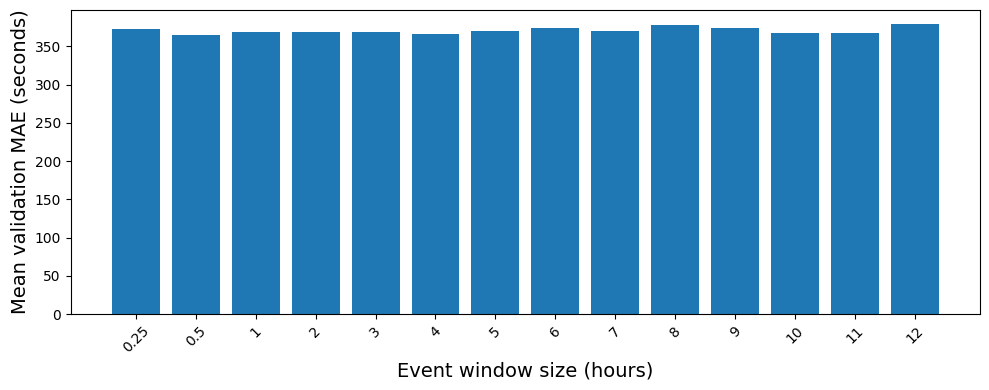

In [6]:
import matplotlib.pyplot as plt

plt.rcParams.update({"axes.labelsize": 14})

window_sizes = [f"{window_hour:g}" for window_hour in window_hours]

plt.figure(figsize=(10, 4))
plt.bar(window_sizes, xgboost_window_validation_losses)
plt.xlabel("Event window size (hours)")
plt.ylabel("Mean validation MAE (seconds)")
# plt.title("XGBoost MAE by event window size")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "xgboost_mae_by_event_window_size_bpa.pdf", dpi=300)
plt.show()

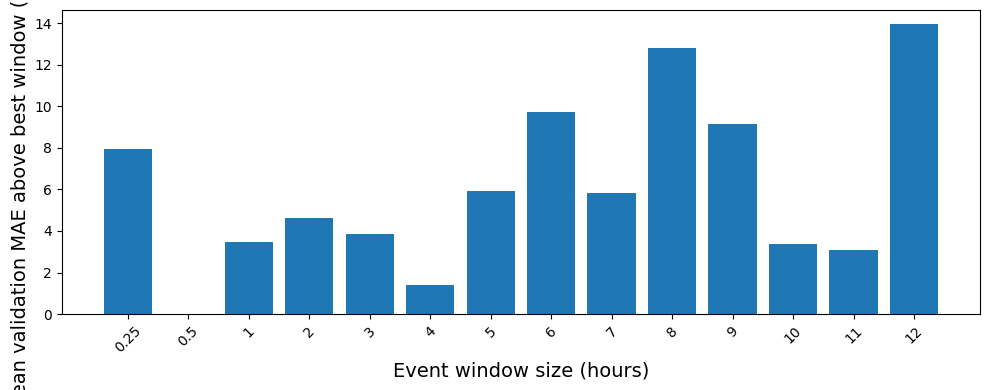

In [7]:
best_loss = min(xgboost_window_validation_losses)
loss_above_best = [loss - best_loss for loss in xgboost_window_validation_losses]

plt.figure(figsize=(10, 4))
plt.bar(window_sizes, loss_above_best)
plt.xlabel("Event window size (hours)")
plt.ylabel("Mean validation MAE above best window (seconds)")
# plt.title(f"XGBoost MAE above best window; best = {best_loss:.2f}s")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "xgboost_mae_above_best_window_bpa.pdf", dpi=300)
plt.show()

# Stage 2: Search parameters


The optimal window is selected automatically from the stage-1 test MAE.

In [8]:
import json

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, PredefinedSplit
from xgboost import XGBRegressor

if len(xgboost_window_validation_losses) != len(window_hours):
    raise RuntimeError(
        "Run stage 1 for every validated window before starting stage 2."
    )
best_window_index = int(np.argmin(xgboost_window_validation_losses))
OPTIMAL_WINDOW_HOURS = window_hours[best_window_index]
optimal_dataset_path = DATA_DIR / f"dataset_winsize{OPTIMAL_WINDOW_HOURS:g}h_when.csv"
if not optimal_dataset_path.exists():
    raise FileNotFoundError(optimal_dataset_path)
SELECTED_WINDOW_METADATA_PATH = WHEN_MODEL_OUTPUT_DIR / "selected_window.json"
selected_window_metadata = {
    "selected_window_hours": float(OPTIMAL_WINDOW_HOURS),
    "selection_metric": "validation_mae_seconds",
    "selection_metric_value": float(
        xgboost_window_validation_losses[best_window_index]
    ),
    "selected_dataset_path": str(optimal_dataset_path),
    "window_metrics_path": str(WINDOW_METRICS_PATH),
    "selection_source": "stage_1_five_fold_cross_validation",
}
SELECTED_WINDOW_METADATA_PATH.write_text(
    json.dumps(selected_window_metadata, indent=4) + "\n"
)
print(
    f"Selected {OPTIMAL_WINDOW_HOURS:g}h window from stage 1 "
    f"(mean validation MAE={xgboost_window_validation_losses[best_window_index]:.6f} seconds)."
)
print(f"Saved selected-window metadata to {SELECTED_WINDOW_METADATA_PATH}")

GRID_SEARCH_OUTPUT_DIR = (
    OUTPUT_DIR / f"xgboost_gridcv_winsize{OPTIMAL_WINDOW_HOURS:g}h_when"
)
GRID_SEARCH_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

REFIT_METRIC = "neg_mean_absolute_error"
GRID_N_JOBS = 1
GRID_VERBOSE = 2

XGB_N_ESTIMATORS_VALUES = [100, 300]
XGB_LEARNING_RATE_VALUES = [0.03, 0.1]
XGB_MAX_DEPTH_VALUES = [3, 5]
XGB_MIN_CHILD_WEIGHT_VALUES = [1, 5]
XGB_SUBSAMPLE_VALUES = [0.8, 1.0]

xgb_param_grid = {
    "n_estimators": XGB_N_ESTIMATORS_VALUES,
    "learning_rate": XGB_LEARNING_RATE_VALUES,
    "max_depth": XGB_MAX_DEPTH_VALUES,
    "min_child_weight": XGB_MIN_CHILD_WEIGHT_VALUES,
    "subsample": XGB_SUBSAMPLE_VALUES,
}

dataset_df = pd.read_csv(optimal_dataset_path)
dataset_df = dataset_df.loc[~dataset_df["is_bg"]].drop(columns="is_bg")
trainval_df = dataset_df[dataset_df["fold_id"].isin(TRAIN_FOLDS)].copy()
test_df = dataset_df[dataset_df["fold_id"] == TEST_FOLD].copy()

X_trainval = trainval_df.drop(columns=DROP_COLUMNS, errors="ignore").select_dtypes(
    include=["number", "bool"]
)
y_trainval = trainval_df[regression_target].astype(float)
trainval_mask = y_trainval.notna()
X_trainval = X_trainval.loc[trainval_mask]
y_trainval = y_trainval.loc[trainval_mask]
cv = PredefinedSplit(trainval_df.loc[trainval_mask, "fold_id"].to_numpy())

X_test = test_df.drop(columns=DROP_COLUMNS, errors="ignore").select_dtypes(
    include=["number", "bool"]
)
y_test = test_df[regression_target].astype(float)
test_mask = y_test.notna()
X_test = X_test.loc[test_mask]
y_test = y_test.loc[test_mask]

xgb_grid_search = GridSearchCV(
    estimator=XGBRegressor(
        objective="reg:quantileerror",
        quantile_alpha=0.5,
        eval_metric="mae",
        tree_method="hist",
        device=DEVICE,
        n_jobs=1,
        random_state=RANDOM_STATE,
    ),
    param_grid=xgb_param_grid,
    scoring={
        "neg_mean_absolute_error": "neg_mean_absolute_error",
        "neg_root_mean_squared_error": "neg_root_mean_squared_error",
        "r2": "r2",
    },
    refit=REFIT_METRIC,
    cv=cv,
    n_jobs=GRID_N_JOBS,
    verbose=GRID_VERBOSE,
    return_train_score=True,
)

xgb_grid_search.fit(X_trainval, y_trainval)
xgb_grid_model_path = WHEN_MODEL_OUTPUT_DIR / "xgboost_grid_search_best.json"
xgb_grid_search.best_estimator_.save_model(xgb_grid_model_path)

xgb_cv_results = pd.DataFrame(xgb_grid_search.cv_results_)
xgb_cv_results.to_csv(GRID_SEARCH_OUTPUT_DIR / "xgboost_cv_results.csv", index=False)

xgb_y_pred = xgb_grid_search.predict(X_test)
xgb_test_mae = mean_absolute_error(y_test, xgb_y_pred)
xgb_test_rmse = mean_squared_error(y_test, xgb_y_pred) ** 0.5
xgb_test_r2 = r2_score(y_test, xgb_y_pred)

xgb_best_params = {
    "refit_metric": REFIT_METRIC,
    "best_cv_mae": float(-xgb_grid_search.best_score_),
    "test_mae": float(xgb_test_mae),
    "test_rmse": float(xgb_test_rmse),
    "test_r2": float(xgb_test_r2),
    "best_params": xgb_grid_search.best_params_,
}
(GRID_SEARCH_OUTPUT_DIR / "xgboost_best_params.json").write_text(
    json.dumps(xgb_best_params, indent=4)
)

xgb_test_predictions = pd.DataFrame(
    {
        "y_true": y_test.to_numpy(),
        "y_pred": xgb_y_pred,
        "absolute_error": np.abs(y_test.to_numpy() - xgb_y_pred),
    }
)
xgb_test_predictions.to_csv(
    GRID_SEARCH_OUTPUT_DIR / "xgboost_test_predictions.csv",
    index=False,
)

xgb_gridcv_summary = pd.DataFrame([xgb_best_params])
xgb_gridcv_summary.to_csv(
    GRID_SEARCH_OUTPUT_DIR / "xgboost_gridcv_summary.csv",
    index=False,
)

print(f"Best CV MAE: {-xgb_grid_search.best_score_:.6f}")
print(f"Test MAE: {xgb_test_mae:.6f}")
print(f"Best params: {xgb_grid_search.best_params_}")
print(f"Saved best grid-search model to {xgb_grid_model_path}")

xgb_gridcv_summary

Selected 0.5h window from stage 1 (mean validation MAE=364.524118 seconds).
Saved selected-window metadata to model_outputs/xgboost_when/selected_window.json
Fitting 5 folds for each of 32 candidates, totalling 160 fits
[CV] END learning_rate=0.03, max_depth=3, min_child_weight=1, n_estimators=100, subsample=0.8; total time=   0.0s
[CV] END learning_rate=0.03, max_depth=3, min_child_weight=1, n_estimators=100, subsample=0.8; total time=   0.0s
[CV] END learning_rate=0.03, max_depth=3, min_child_weight=1, n_estimators=100, subsample=0.8; total time=   0.0s
[CV] END learning_rate=0.03, max_depth=3, min_child_weight=1, n_estimators=100, subsample=0.8; total time=   0.0s
[CV] END learning_rate=0.03, max_depth=3, min_child_weight=1, n_estimators=100, subsample=0.8; total time=   0.0s
[CV] END learning_rate=0.03, max_depth=3, min_child_weight=1, n_estimators=100, subsample=1.0; total time=   0.0s
[CV] END learning_rate=0.03, max_depth=3, min_child_weight=1, n_estimators=100, subsample=1.0; t

,refit_metric,best_cv_mae,test_mae,test_rmse,test_r2,best_params
0,neg_mean_absolute_error,355.334232,374.254247,449.432897,0.922108,"{'learning_rate': 0.1, 'max_depth': 3, 'min_ch..."


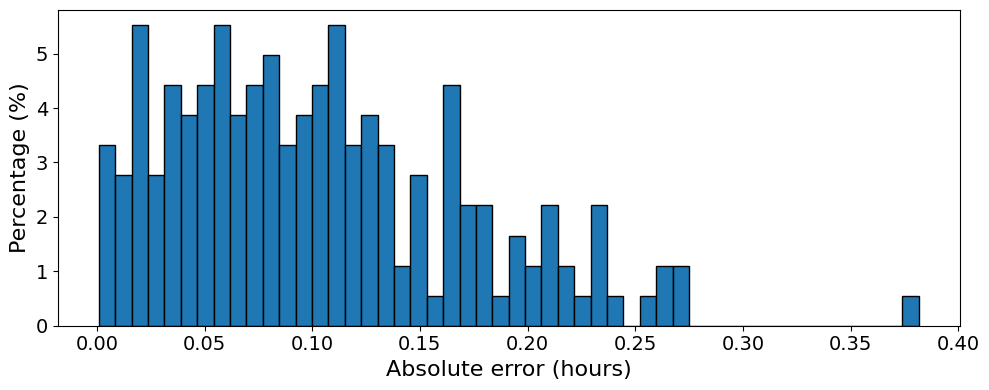

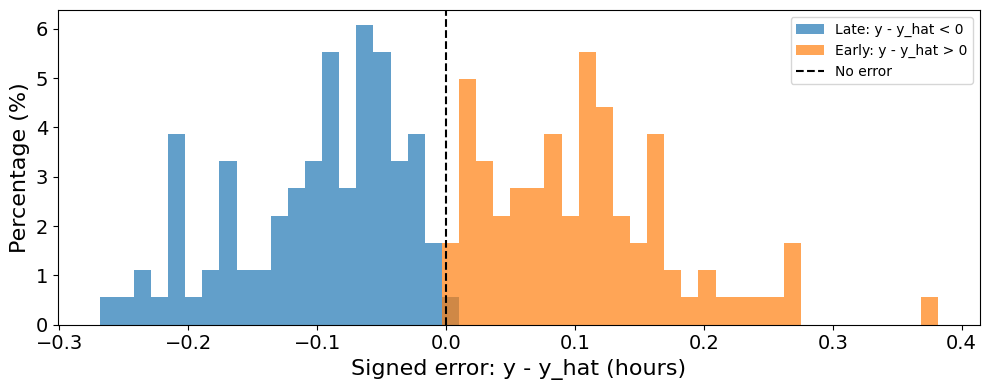

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

absolute_errors = xgb_test_predictions["absolute_error"]
absolute_errors_hours = absolute_errors / SECONDS_PER_HOUR
absolute_error_weights = np.full(
    absolute_errors_hours.shape, 100 / len(absolute_errors_hours)
)

plt.figure(figsize=(10, 4))
plt.hist(
    absolute_errors_hours, bins=50, weights=absolute_error_weights, edgecolor="black"
)
plt.xlabel("Absolute error (hours)", fontsize=16)
plt.ylabel("Percentage (%)", fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
# plt.title("XGBoost absolute error distribution")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "xgboost_absolute_error_distribution_bpa.pdf", dpi=300)
plt.show()
signed_errors = xgb_test_predictions["y_true"] - xgb_test_predictions["y_pred"]
signed_errors_hours = signed_errors / SECONDS_PER_HOUR
early_errors_hours = signed_errors_hours[signed_errors_hours > 0]
late_errors_hours = signed_errors_hours[signed_errors_hours < 0]
signed_error_bins_hours = np.linspace(
    signed_errors_hours.min(), signed_errors_hours.max(), 50
)
signed_error_total = len(signed_errors_hours)
late_error_weights = np.full(late_errors_hours.shape, 100 / signed_error_total)
early_error_weights = np.full(early_errors_hours.shape, 100 / signed_error_total)

plt.figure(figsize=(10, 4))
plt.hist(
    late_errors_hours,
    bins=signed_error_bins_hours,
    weights=late_error_weights,
    alpha=0.7,
    label="Late: y - y_hat < 0",
)
plt.hist(
    early_errors_hours,
    bins=signed_error_bins_hours,
    weights=early_error_weights,
    alpha=0.7,
    label="Early: y - y_hat > 0",
)
plt.axvline(0, color="black", linestyle="--", label="No error")
plt.xlabel("Signed error: y - y_hat (hours)", fontsize=16)
plt.ylabel("Percentage (%)", fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
# plt.title("XGBoost signed error distribution: early vs late predictions")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "xgboost_signed_error_distribution_bpa.pdf", dpi=300)
plt.show()

# Train weighted model

In [10]:
LATE_PREDICTION_PENALTY = 15.0


def late_penalty_squared_error(y_true, y_pred):
    residual = y_pred - y_true
    weights = np.where(residual > 0, LATE_PREDICTION_PENALTY, 1.0)
    grad = 2.0 * weights * residual
    hess = 2.0 * weights
    return grad, hess


late_penalty_xgb_model = XGBRegressor(
    objective=late_penalty_squared_error,
    eval_metric="mae",
    tree_method="hist",
    device=DEVICE,
    n_jobs=1,
    random_state=RANDOM_STATE,
    **xgb_grid_search.best_params_,
)
late_penalty_xgb_model.fit(X_trainval, y_trainval)
late_penalty_model_path = WHEN_MODEL_OUTPUT_DIR / "xgboost_late_penalty.json"
late_penalty_xgb_model.save_model(late_penalty_model_path)

late_penalty_y_pred = late_penalty_xgb_model.predict(X_test)
late_penalty_signed_errors = y_test.to_numpy() - late_penalty_y_pred
late_penalty_absolute_errors = np.abs(late_penalty_signed_errors)
late_prediction_mask = late_penalty_signed_errors < 0
early_prediction_mask = late_penalty_signed_errors > 0

late_weighted_absolute_errors = np.where(
    late_prediction_mask,
    LATE_PREDICTION_PENALTY * late_penalty_absolute_errors,
    late_penalty_absolute_errors,
)

late_penalty_metrics = {
    "mae": mean_absolute_error(y_test, late_penalty_y_pred),
    "late_penalized_mae": late_weighted_absolute_errors.mean(),
    "rmse": mean_squared_error(y_test, late_penalty_y_pred) ** 0.5,
    "r2": r2_score(y_test, late_penalty_y_pred),
    "late_prediction_rate": late_prediction_mask.mean(),
    "early_prediction_rate": early_prediction_mask.mean(),
    "late_prediction_penalty": LATE_PREDICTION_PENALTY,
    "best_params": xgb_grid_search.best_params_,
}

late_penalty_test_predictions = pd.DataFrame(
    {
        "y_true": y_test.to_numpy(),
        "y_pred": late_penalty_y_pred,
        "signed_error": late_penalty_signed_errors,
        "absolute_error": late_penalty_absolute_errors,
        "late_weighted_absolute_error": late_weighted_absolute_errors,
        "is_late_prediction": late_prediction_mask,
    }
)

print(f"MAE: {late_penalty_metrics['mae']:.6f} seconds")
print(
    "Late-penalized MAE "
    f"(late predictions x{LATE_PREDICTION_PENALTY:g}): "
    f"{late_penalty_metrics['late_penalized_mae']:.6f} seconds"
)
print(f"Late prediction rate: {late_penalty_metrics['late_prediction_rate']:.6%}")
print(f"Early prediction rate: {late_penalty_metrics['early_prediction_rate']:.6%}")
print(f"Saved late-penalty model to {late_penalty_model_path}")

late_penalty_metrics

MAE: 410.993660 seconds
Late-penalized MAE (late predictions x15): 1381.481737 seconds
Late prediction rate: 34.254144%
Early prediction rate: 65.745856%
Saved late-penalty model to model_outputs/xgboost_when/xgboost_late_penalty.json


{'mae': 410.99365997314453,
 'late_penalized_mae': np.float64(1381.4817370841515),
 'rmse': 534.8509391107765,
 'r2': 0.8896861800890921,
 'late_prediction_rate': np.float64(0.3425414364640884),
 'early_prediction_rate': np.float64(0.6574585635359116),
 'late_prediction_penalty': 15.0,
 'best_params': {'learning_rate': 0.1,
  'max_depth': 3,
  'min_child_weight': 5,
  'n_estimators': 100,
  'subsample': 1.0}}

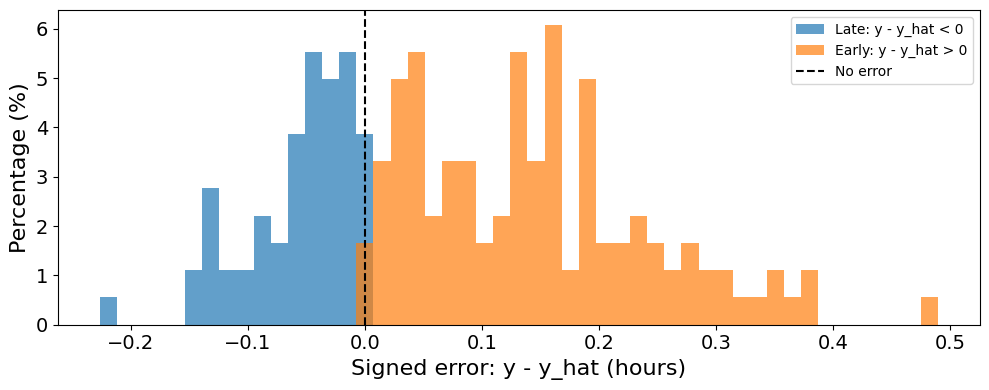

Unweighted model late prediction rate: 51.381215%
Unweighted model early prediction rate: 48.618785%
Weighted model late prediction rate: 34.254144%
Weighted model early prediction rate: 65.745856%


In [11]:
unweighted_signed_errors = (
    xgb_test_predictions["y_true"] - xgb_test_predictions["y_pred"]
)
weighted_signed_errors = late_penalty_test_predictions["signed_error"]
weighted_early_errors = weighted_signed_errors[weighted_signed_errors > 0]
weighted_late_errors = weighted_signed_errors[weighted_signed_errors < 0]
weighted_signed_errors_hours = weighted_signed_errors / SECONDS_PER_HOUR
weighted_early_errors_hours = weighted_signed_errors_hours[
    weighted_signed_errors_hours > 0
]
weighted_late_errors_hours = weighted_signed_errors_hours[
    weighted_signed_errors_hours < 0
]
weighted_signed_error_bins_hours = np.linspace(
    weighted_signed_errors_hours.min(),
    weighted_signed_errors_hours.max(),
    50,
)
weighted_signed_error_total = len(weighted_signed_errors_hours)
weighted_late_error_weights = np.full(
    weighted_late_errors_hours.shape,
    100 / weighted_signed_error_total,
)
weighted_early_error_weights = np.full(
    weighted_early_errors_hours.shape,
    100 / weighted_signed_error_total,
)

plt.figure(figsize=(10, 4))
plt.hist(
    weighted_late_errors_hours,
    bins=weighted_signed_error_bins_hours,
    weights=weighted_late_error_weights,
    alpha=0.7,
    label="Late: y - y_hat < 0",
)
plt.hist(
    weighted_early_errors_hours,
    bins=weighted_signed_error_bins_hours,
    weights=weighted_early_error_weights,
    alpha=0.7,
    label="Early: y - y_hat > 0",
)
plt.axvline(0, color="black", linestyle="--", label="No error")
plt.xlabel("Signed error: y - y_hat (hours)", fontsize=16)
plt.ylabel("Percentage (%)", fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
# plt.title("Late-penalized XGBoost signed error distribution")
plt.legend()
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "late_penalized_xgboost_signed_error_distribution_bpa.pdf", dpi=300
)
plt.show()

print(
    f"Unweighted model late prediction rate: "
    f"{(unweighted_signed_errors < 0).mean():.6%}"
)
print(
    f"Unweighted model early prediction rate: "
    f"{(unweighted_signed_errors > 0).mean():.6%}"
)
print(f"Weighted model late prediction rate: {(weighted_signed_errors < 0).mean():.6%}")
print(
    f"Weighted model early prediction rate: {(weighted_signed_errors > 0).mean():.6%}"
)